In [44]:
# Modelling
# Model 1 : RandomForestClassifier

In [13]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [14]:
folder_name = "/Users/abhinandho/Desktop/Trader Behaviour & Performance Analytics/data/"
charts_path = "/Users/abhinandho/Desktop/Trader Behaviour & Performance Analytics/charts/"

In [15]:
# Load
df_daily = pd.read_csv(folder_name + "df_daily.csv")

In [16]:
# Fix date
df_daily['date'] = pd.to_datetime(df_daily['date'])

In [17]:
print(df_daily.shape)
print(df_daily.columns.tolist())

(1690, 15)
['date', 'account', 'daily_pnl', 'trade_count', 'avg_size_usd', 'total_fees', 'win_rate', 'long_ratio', 'net_pnl', 'value', 'classification', 'sentiment_binary', 'risk_segment', 'frequency_segment', 'performance_segment']


In [18]:
#create with target variable - was this trader profitable that day
df_daily['is_profitable'] = (df_daily['net_pnl']> 0).astype(int)

In [19]:
#check distribution
print(df_daily['is_profitable'].value_counts())

is_profitable
1    1457
0     233
Name: count, dtype: int64


In [20]:
print(df_daily['is_profitable'].value_counts(normalize = True).round(2))

is_profitable
1    0.86
0    0.14
Name: proportion, dtype: float64


In [22]:
# Define Features and Target 

features = ['value','trade_count','avg_size_usd','total_fees','win_rate','long_ratio']

X = df_daily[features]
y = df_daily['is_profitable']

In [23]:
X_train, X_test, y_train,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [24]:
print(f"Training rows:  {X_train.shape[0]}")
print(f"Testing rows:   {X_test.shape[0]}")
print(f"\nTrain profitable %: {y_train.mean():.2f}")
print(f"Test profitable %:  {y_test.mean():.2f}")

Training rows:  1352
Testing rows:   338

Train profitable %: 0.86
Test profitable %:  0.86


In [29]:
from sklearn.utils.class_weight import compute_class_weight

#handle imbalanced data using lass weights

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes = np.array([0,1]),
    y = y_train
)
weight_dict = {0: class_weights[0],1:class_weights[1]}
print(f"Class weights: {weight_dict}")

Class weights: {0: np.float64(3.6344086021505375), 1: np.float64(0.5797598627787307)}


In [33]:
rf_model = RandomForestClassifier(
    n_estimators = 100,
    class_weight= weight_dict,
    random_state = 42
)

rf_model.fit(X_train, y_train)
print("Model trained!")

Model trained!


=== Model Performance ===
                precision    recall  f1-score   support

Not Profitable       0.93      0.81      0.86        47
    Profitable       0.97      0.99      0.98       291

      accuracy                           0.96       338
     macro avg       0.95      0.90      0.92       338
  weighted avg       0.96      0.96      0.96       338



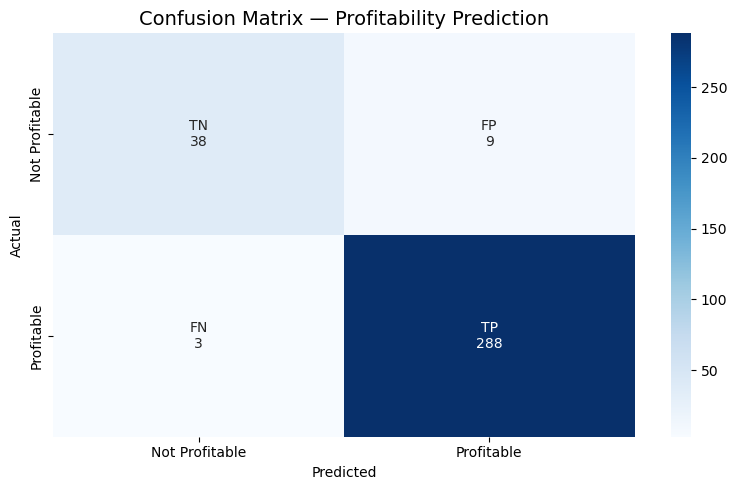

In [35]:
# Make predictions on test data
y_pred = rf_model.predict(X_test)

# Classification report
print("=== Model Performance ===")
print(classification_report(y_test, y_pred, 
      target_names=['Not Profitable', 'Profitable']))

# Confusion matrix with TP TN FP FN labels
cm = confusion_matrix(y_test, y_pred)

labels = [
    ['TN\n38', 'FP\n9'],
    ['FN\n3',  'TP\n288']
]

plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=np.array(labels), fmt='', cmap='Blues',
            xticklabels=['Not Profitable', 'Profitable'],
            yticklabels=['Not Profitable', 'Profitable'])
plt.title('Confusion Matrix — Profitability Prediction', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(charts_path + 'chart_12_confusion_matrix.png', dpi=150)
plt.show()

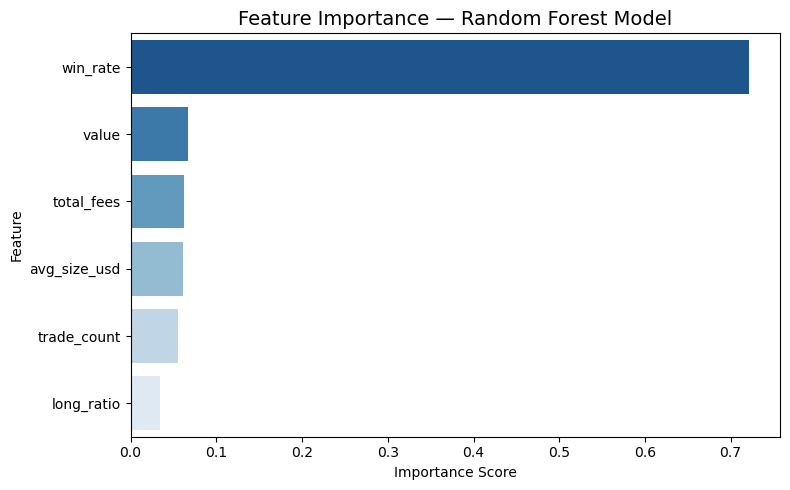

        feature  importance
4      win_rate    0.721503
0         value    0.066407
3    total_fees    0.061772
2  avg_size_usd    0.061347
1   trade_count    0.054676
5    long_ratio    0.034295


In [37]:
# Feature importance
importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='importance', y='feature',
            hue='feature',
            palette='Blues_r',
            legend=False)
plt.title('Feature Importance — Random Forest Model', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(charts_path + 'chart_13_feature_importance.png', dpi=150)
plt.show()

print(importance)

In [ ]:
"If I know your win rate — I can predict with high confidence whether today will be profitable. Everything else is secondary."

In [ ]:
# End Of Notebook